In [34]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model

### 1. Load and apply preprocessing techniques
Preprocessing:
- normalizing pixel value to [0,1]
- expanding dimesions

In [42]:
x_train = np.load('datasets/fashion_mnist_x_train.npy')
x_test = np.load('datasets/fashion_mnist_x_test.npy')

# Normalize images to [0,1] range
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Ensure dataset has the correct shape
if len(x_train.shape) == 3:  # If shape is (samples, height, width), add a channel dimension
    x_train = np.expand_dims(x_train, axis=-1)
    x_test = np.expand_dims(x_test, axis=-1)

input_shape = x_train.shape[1:]  # Now it should be (height, width, channels)

# Print dataset details
print(f"Train shape: {x_train.shape}, Test shape: {x_test.shape}")
print(f"Pixel range: {x_train.min()} to {x_train.max()}")


Train shape: (60000, 28, 28, 1), Test shape: (10000, 28, 28, 1)
Pixel range: 0.0 to 1.0


### 2. Encoder Network with Constraints


In [36]:
z_dim = 2  # Keeping it as 2 as per requirement

def build_encoder():
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, kernel_size=3, strides=2, padding="same", activation=tf.nn.leaky_relu)(inputs)
    x = layers.Conv2D(64, kernel_size=3, strides=2, padding="same", activation=tf.nn.leaky_relu)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation=tf.nn.leaky_relu)(x)
    
    # Mean and log variance layers
    z_mean = layers.Dense(z_dim, name="z_mean")(x)
    z_log_var = layers.Dense(z_dim, name="z_log_var")(x)
    
    # Sampling function
    def sampling(args):
        z_mean, z_log_var = args
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon
    
    z = layers.Lambda(sampling, name="z")([z_mean, z_log_var])
    
    encoder = Model(inputs, [z_mean, z_log_var, z], name="encoder")
    return encoder

### 3. Decoder Network with constraints

In [37]:
def build_decoder():
    latent_inputs = keras.Input(shape=(z_dim,))
    x = layers.Dense(7 * 7 * 64, activation=tf.nn.leaky_relu)(latent_inputs)
    x = layers.Reshape((7, 7, 64))(x)
    x = layers.Conv2DTranspose(64, kernel_size=3, strides=2, padding="same", activation=tf.nn.leaky_relu)(x)
    x = layers.Conv2DTranspose(32, kernel_size=3, strides=2, padding="same", activation=tf.nn.leaky_relu)(x)
    x = layers.Conv2DTranspose(input_shape[-1], kernel_size=3, strides=1, padding="same", activation="sigmoid")(x)
    decoder = Model(latent_inputs, x, name="decoder")
    return decoder

encoder = build_encoder()
decoder = build_decoder()

### 4. Variational Autoencoder(VAE) Model with Hyperparameter tuning of autoencoder with constraints

In [ ]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
    
    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstructed = self.decoder(z)
        return reconstructed

vae = VAE(encoder, decoder)

# Loss function (Reconstruction + KL divergence loss)
def vae_loss(y_true, y_pred):
    reconstruction_loss = keras.losses.MeanSquaredError()(y_true, y_pred)
    z_mean, z_log_var, _ = encoder(y_true)
    kl_loss = -0.5 * tf.reduce_mean(z_log_var - tf.square(z_mean) - tf.exp(z_log_var) + 1)
    return reconstruction_loss + kl_loss

### 5. Compile and Train Model with Early Stopping

In [51]:
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005), loss=vae_loss)

# Train with early stopping
callbacks = [keras.callbacks.EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)]
vae.fit(x_train, x_train, epochs=30, batch_size=32, validation_data=(x_test, x_test), callbacks=callbacks)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 19ms/step - loss: 0.0871 - val_loss: 0.0867
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - loss: 0.0868 - val_loss: 0.0867
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - loss: 0.0871 - val_loss: 0.0868
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 22ms/step - loss: 0.0870 - val_loss: 0.0867
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - loss: 0.0870 - val_loss: 0.0867
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - loss: 0.0868 - val_loss: 0.0867
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - loss: 0.0871 - val_loss: 0.0867
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - loss: 0.0870 - val_loss: 0.0867
Epoch 9/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 13ms/step - loss: 0.0873 - val_loss: 0.0867
Epoch 10/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 0.0871 - val_loss: 0.0867
Epoch 11/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - loss: 0.0870 - val_loss: 0.0867
Epoch 12

### Visualizing reconstructed images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


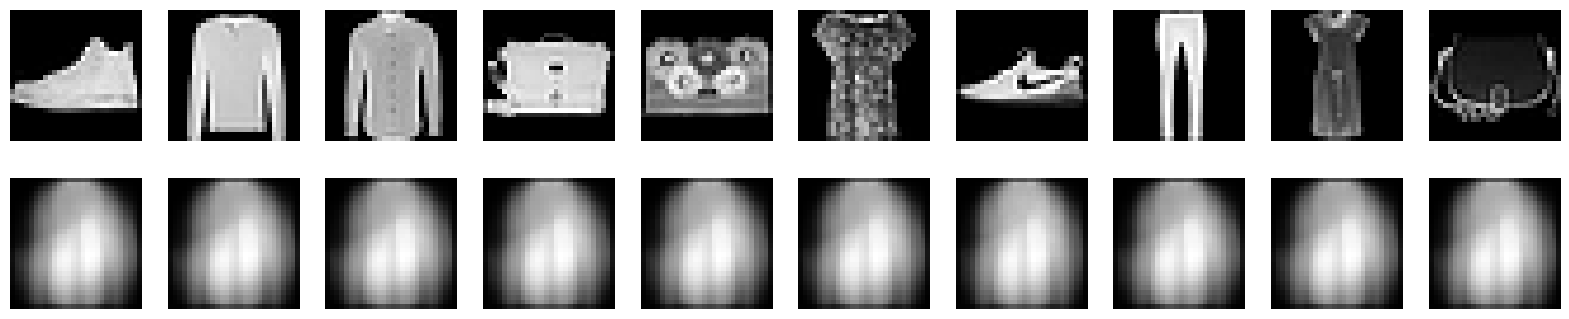

In [52]:
def visualize_reconstructions():
    n = 10
    indices = np.random.randint(0, x_test.shape[0], n)
    original_images = x_test[indices]
    reconstructed_images = vae.predict(original_images)
    
    fig, axes = plt.subplots(2, n, figsize=(20, 4))
    for i in range(n):
        axes[0, i].imshow(original_images[i].squeeze(), cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(reconstructed_images[i].squeeze(), cmap='gray')
        axes[1, i].axis('off')
    plt.show()

visualize_reconstructions()

### Evaluate autoencoder performance with PSNR and SSIM

In [41]:
def psnr(y_true, y_pred):
    max_pixel = 1.0  # Since images are normalized in range [0,1]
    mse = np.mean((y_true - y_pred) ** 2)
    return 20 * np.log10(max_pixel / np.sqrt(mse))

# Compute SSIM using TensorFlow
def ssim(y_true, y_pred):
    return tf.image.ssim(y_true, y_pred, max_val=1.0)

# Evaluate on test set
reconstructed_images = vae.predict(x_test[:100])
psnr_values = [psnr(x_test[i], reconstructed_images[i]) for i in range(100)]
ssim_values = [ssim(x_test[i], reconstructed_images[i]).numpy() for i in range(100)]

# Print evaluation metrics
print("Average PSNR:", np.mean(psnr_values))
print("Average SSIM:", np.mean(ssim_values))


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step 
Average PSNR: 10.653301561070004
Average SSIM: 0.13673958
